In [5]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from astropy.cosmology import Planck18 as cosmo  
from astropy import units as u  

from astropy.coordinates import SkyCoord  # For coordinate transformations
import scipy

In [6]:
SIGMA_T = 6.6524587158e-29  # Thomson cross section (m^2)
M_E = 9.10938356e-31        # Electron mass (kg)
C = 299792458.0             # Speed of light (m/s)
MPC_TO_M = 3.08567758e22    # Megaparsec to meters conversion factor

In [7]:
import pathlib
agora_home_path = pathlib.Path("/fs/scratch/PCON0003/nddalal/agora")
tSZ_map_path = agora_home_path / "tsz/unl/y_map.fits"
shear_path = agora_home_path / 'lss/galaxy_shear/lsst_y1_srd/maps/raytrace16384_ip20.kg1g2_nside16384_shelledge_lsst_y1_srcs_zbin1_fullsky_lmax24576.fits'

In [8]:
halo_path = agora_home_path / "halocat/agora_halolc_len_rot_4_v050223.npz"

In [9]:
halos = np.load(halo_path)
tsz_map = hp.read_map(tSZ_map_path)
kappa_map = hp.read_map(shear_path) 

In [6]:
np.max(halos['z'])

0.042107457856749964

In [7]:
most_massive = np.argmax(halos['m500c'])

In [8]:
mask = (halos['m500c']>1e14)

In [9]:
halos['m500c'][mask].size

23

In [10]:
np.log10(np.mean(halos['m500c']))

11.795909907790277

In [11]:
halos['ura'].size

112297

In [12]:
fov_deg = 0.5
pixel_scale_arcmin = 0.1
npix = int(fov_deg * 60 / pixel_scale_arcmin)

In [13]:
ra_deg = halos['ura'][2]
dec_deg = halos['udec'][2]

In [14]:
np.median(halos['z'][mask])

0.03775161798161086

In [15]:
tsz_map = tsz_map - np.mean(tsz_map)

In [16]:
tsz_list = []
kappa_list = []
for i in range(len(halos['m500c'][mask])):
    ra_deg = halos['ura'][mask][i]
    dec_deg = halos['udec'][mask][i]
    patch_tsz = hp.gnomview(tsz_map, rot=(ra_deg, dec_deg), xsize=npix, reso = pixel_scale_arcmin, title = "tSZ", return_projected_map=True, cmap = 'plasma', hold = True, no_plot = True)
    patch_kappa = hp.gnomview(kappa_map, rot=(ra_deg, dec_deg), xsize=npix, reso = pixel_scale_arcmin, title = r"$\kappa$",return_projected_map=True, hold = True, no_plot = True)
    tsz_list.append(patch_tsz)
    kappa_list.append(patch_kappa)
#plt.axes(ax1)
#patch_tsz = hp.gnomview(tsz_map, rot=(ra_deg, dec_deg), xsize=npix, reso = pixel_scale_arcmin, title = "tSZ", return_projected_map=True, cmap = 'plasma', hold = True)
#plt.axes(ax2)
#patch_kappa = hp.gnomview(kappa_map, rot=(ra_deg, dec_deg), xsize=npix, reso = pixel_scale_arcmin, title = r"$\kappa$",return_projected_map=True, hold = True)

In [17]:
hp.get_map_size(tsz_map)

805306368

In [18]:
np.median(tsz_map)

-3.001535e-07

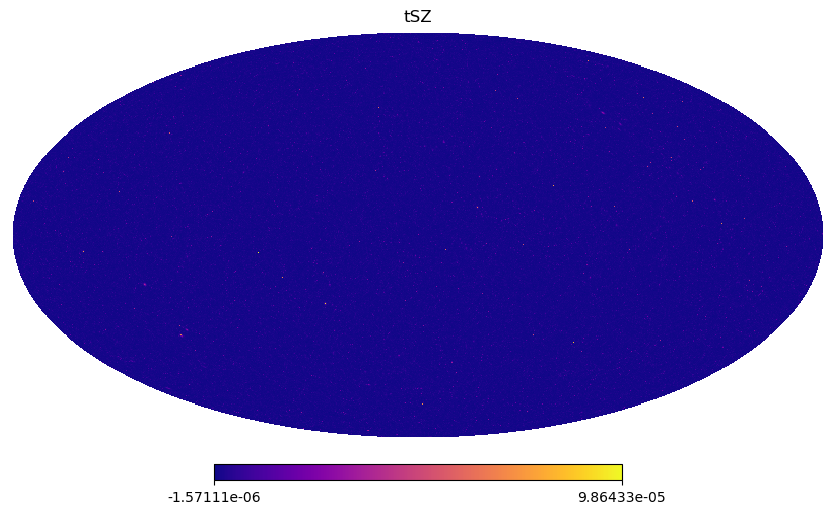

In [19]:
hp.mollview(tsz_map, title = "tSZ", cmap = 'plasma')

In [20]:
print([np.max(cluster) for cluster in tsz_list])

[2.8844149710494094e-05, 1.6203297491301782e-05, 9.433148989046458e-06, 2.9135431759641506e-05, 2.3642876840312965e-05, 1.433246779924957e-05, 1.4167470908432733e-05, 2.1776480934931897e-05, 5.299145050230436e-05, 2.0217124983901158e-05, 3.296728391433135e-05, 7.79578294896055e-06, 2.0846040570177138e-05, 6.796618981752545e-05, 1.2881910151918419e-05, 1.7097756426665e-05, 2.471088373567909e-05, 4.062668085680343e-05, 2.579071770014707e-05, 1.3107800441503059e-05, 3.374370498931967e-05, 1.7182890587719157e-05, 2.6485986381885596e-05]


In [21]:
np.max(tsz_stack)

NameError: name 'tsz_stack' is not defined

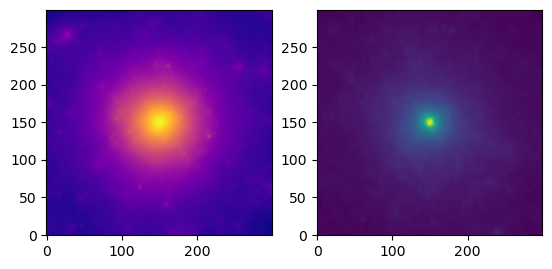

In [23]:
fig, (ax1, ax2) = plt.subplots(ncols = 2)
plt.axes(ax1)
tsz_stack = np.mean(tsz_list, axis = 0)
plt.imshow(tsz_stack, origin = 'lower', cmap = 'plasma')
plt.axes(ax2)
kappa_stack = np.mean(kappa_list, axis = 0)
plt.imshow(kappa_stack, origin = 'lower', cmap = 'viridis')

In [24]:
tsz_scatter = np.std(tsz_list, axis = 0)
kappa_scatter = np.std(kappa_list, axis = 0)

In [25]:
def radial_profile(data, center = None, nbins = 20):
    if center is None:
        center = (data.shape[1]//2, data.shape[0]//2)
    y, x = np.indices((data.shape))
    r = np.sqrt((x - center[0])**2 + (y - center[1])**2)
    #r = r.astype(np.int)
    r_flat = r.flatten()
    image_flat = data.flatten()
    
    rmax = np.max(r)
    bins = np.linspace(0, rmax, nbins+1)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    profile_sum, _ = np.histogram(r_flat, bins=bins, weights=image_flat)
    pixel_count, _ = np.histogram(r_flat, bins=bins)
    radial_profile = np.divide(profile_sum, pixel_count, out=np.zeros_like(profile_sum), where=pixel_count!=0)
    
    return bin_centers, radial_profile

In [26]:
_ , prof_scatter_tsz = radial_profile(tsz_scatter)
_, prof_scatter_kappa = radial_profile(kappa_scatter)

In [27]:
r_tsz, prof_tsz = radial_profile(tsz_stack)
r_kappa, prof_kappa = radial_profile(kappa_stack)

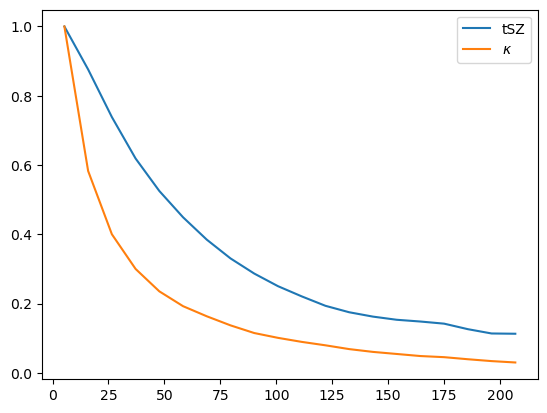

In [28]:
plt.plot(r_tsz, prof_tsz/np.max(prof_tsz), label = "tSZ")
plt.plot(r_kappa, prof_kappa/np.max(prof_kappa), label = r"$\kappa$") 
#plt.yscale('log') 
plt.legend()

# Agora Theory

In [29]:
import BaryonForge as bfg
import pyccl as ccl

In [30]:
params = bfg.Profiles.Mead20.Tagn2pars(8.0, mode = 'MatterPressure')
cosmo = ccl.Cosmology(Omega_c = 0.26, h = 0.7, Omega_b = 0.04, sigma8 = 0.8, n_s = 0.96)

In [31]:
print(params)

{'A_star': 0.0309, 'nu_A_star': -0.0082, 'M_star': 3525347721936.935, 'nu_M_star': -0.3073, 'eta': -0.3505, 'eps1': -0.12533, 'nu_eps1': -0.011069999999999997, 'Gamma': 1.19657, 'nu_Gamma': 0.0, 'M_0': 252861063380624.53, 'T_w': 4586274.0270803645, 'nu_T_w': -0.06167, 'eps2': 0.0, 'mean_molecular_weight': 0.59, 'eta_b': 0.5, 'sigma_star': 1.2, 'beta': 0.6, 'epsilon_h': 0.015, 'p': 0.3, 'q': 0.707, 'alpha': 1.0314}


In [32]:
pressure = bfg.Profiles.Mead20.Pressure(**params)

In [33]:
r = np.logspace(-2, 0, 50)

In [34]:
mead_pressure = pressure._real(cosmo, r, 1e14, 1)

In [35]:
def reproj_pressure(R_proj, pressure_func, cosmo, mass, scale_factor, z = None):
    if z is not None: 
        scale_factor = 1.0/(1.0 + z)
    
    prefac = SIGMA_T / (M_E * C**2) #tSZ

    def integrand(r, R):
        if r == R:
            return 0
        p_val = pressure_func(cosmo, r, mass, scale_factor)
        return 2*p_val*r/np.sqrt(r**2 - R**2)
    
    if np.isscalar(R_proj):
        result, error = scipy.integrate.quad(integrand, R_proj, np.inf, args=(R_proj,))
        return result * prefac 
    
    y_values = []
    for R in R_proj:
        result, error = scipy.integrate.quad(integrand, R, np.inf, args=(R,))
        y_values.append(result * prefac)
    
    return np.array(y_values) * prefac

In [36]:
R_proj = np.logspace(-2, 0, 50)
y_vals = reproj_pressure(R_proj, pressure._real, cosmo, 1e14, 1, z = 0.04)

In [37]:
np.log10(np.mean(halos['m500c'][mask]))

14.17275518093578

In [45]:
prof_scatter_kappa/= len(kappa_list)

In [38]:
mead_dmb_projected = bfg.Profiles.Mead20.DarkMatter(**params)._projected(cosmo, R_proj, 2.2e14, 1)

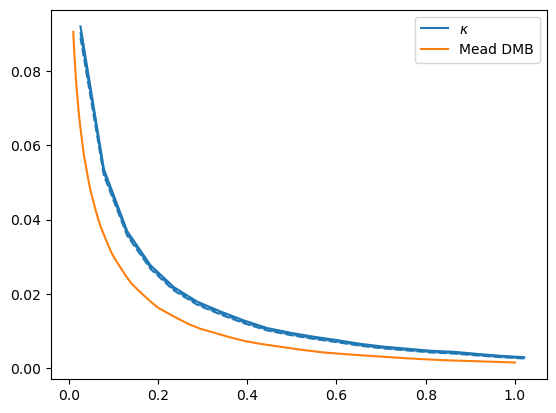

In [46]:
plt.plot(r_kappa/200*0.987, prof_kappa + prof_scatter_kappa, label = r"$\kappa$")
plt.plot(r_kappa/200*0.987, prof_kappa - prof_scatter_kappa, color = 'C0', ls = '--')
plt.plot(r_kappa/200*0.987, prof_kappa, color = 'C0', ls = '--')
plt.fill_between(r_kappa/200*0.987, prof_kappa - prof_scatter_kappa, prof_kappa + prof_scatter_kappa, color = 'C0', alpha = 0.3)
plt.plot(R_proj, mead_dmb_projected/np.max(mead_dmb_projected)*np.max(prof_kappa), label = "Mead DMB")
plt.legend()

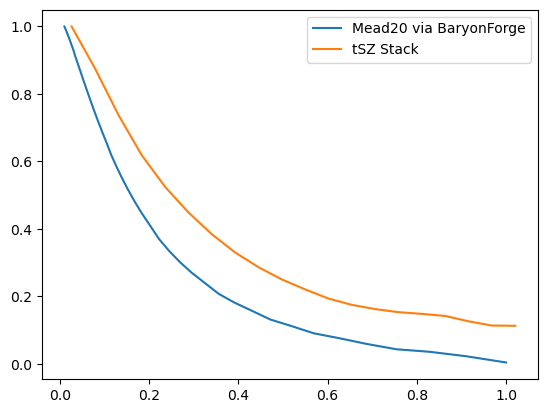

In [40]:
plt.plot(r, y_vals/np.max(y_vals), label = "Mead20 via BaryonForge")
plt.plot(r_tsz/200*0.987, prof_tsz/np.max(prof_tsz), label = "tSZ Stack")
plt.legend()

In [41]:
mead_pressure_projected = pressure.projected(cosmo, r, 2.2e14, 1)

In [42]:
prof_tsz

array([1.26274903e-05, 1.10620776e-05, 9.32729715e-06, 7.81617938e-06,
       6.63253038e-06, 5.67385064e-06, 4.85843156e-06, 4.17443689e-06,
       3.62258551e-06, 3.16300068e-06, 2.79139909e-06, 2.44745064e-06,
       2.21271316e-06, 2.05379200e-06, 1.93885485e-06, 1.87480139e-06,
       1.79709897e-06, 1.59606076e-06, 1.43919335e-06, 1.42940947e-06])

In [43]:
prof_scatter_tsz /= np.sqrt(len(tsz_list))

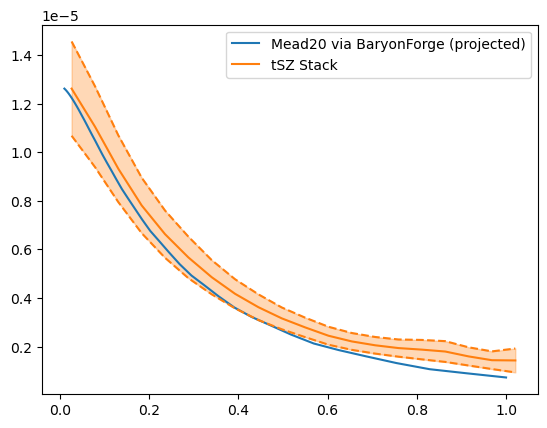

In [44]:
#plt.plot(r, y_vals/np.max(y_vals), label = "Mead20 via BaryonForge")
plt.plot(r, mead_pressure_projected/np.max(mead_pressure_projected) * np.max(prof_tsz), label = "Mead20 via BaryonForge (projected)")
plt.plot(r_tsz/200*0.987, prof_tsz+prof_scatter_tsz, color = 'C1', linestyle = 'dashed')
plt.plot(r_tsz/200*0.987, (prof_tsz-prof_scatter_tsz), color = 'C1', linestyle = 'dashed')
plt.plot(r_tsz/200*0.987, prof_tsz, label = "tSZ Stack", color = 'C1')
plt.fill_between(r_tsz/200*0.987, prof_tsz-prof_scatter_tsz, prof_tsz+prof_scatter_tsz, color = 'C1', alpha = 0.3)
plt.legend()

In [34]:
halos.files

['haloid',
 'pid',
 'upid',
 'ura',
 'udec',
 'vlos',
 'z',
 'mpeak',
 'vpeak',
 'm200b',
 'rs',
 'vphi',
 'vtht',
 'rvir',
 'mvir',
 'm200c',
 'm500c',
 'lra',
 'ldec',
 'mag',
 'R_real',
 'R_imag']

In [133]:
main_halo_mask = (halos['upid']==-1)

In [137]:
len(halos['m200c'][main_halo_mask])

98767

In [134]:
m200cdef = ccl.halos.massdef.MassDef(200, 'critical')
class MyConcentrationRelation:
    def __init__(self, mass_def = m200cdef):
        self.mass_def = mass_def
    def __call__(self, cosmo, M, a):
        r200c_interp = m200cdef.get_radius(cosmo, halos['m200c'][main_halo_mask], a)
        return np.interp(M, halos['m200c'][main_halo_mask], r200c_interp/(0.001*halos['rs'][main_halo_mask]))

In [130]:
r200c_interp = m200cdef.get_radius(cosmo, halos['m200c'][mask], 1)
print(r200c_interp)

[1.48266036 1.10987391 1.12062405 1.36799838 1.30018622 1.07138292
 1.17563575 1.11432141 1.62475409 1.24153917 1.25112634 1.14808971
 1.12701783 1.05921438 1.21685046 1.12473275 1.24172893 1.17100271
 1.12403849 1.19358668 1.19904503 1.22102508 1.24460651]


In [135]:
blah = MyConcentrationRelation()

In [157]:
r200c_interp = m200cdef.get_radius(cosmo, halos['m200c'][main_halo_mask], 1)

In [158]:
main_halo_mask &= halos['m200c'] > 10**13.5

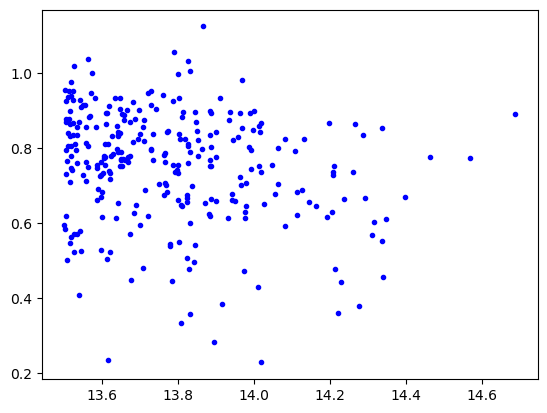

In [161]:
plt.plot(np.log10(halos['m200c'][main_halo_mask]),np.log10( r200c_interp/(0.001*halos['rs'][main_halo_mask])), 'b.')

In [55]:
pressure_with_correct_cm = pressure = bfg.Profiles.Mead20.Pressure(c_M_relation = MyConcentrationRelation, **params)

In [56]:
pressure_projected_cm = pressure_with_correct_cm.projected(cosmo, r, 1e14, 1)

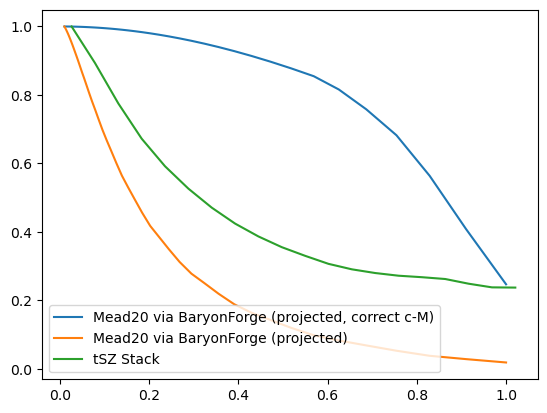

In [58]:
#plt.plot(r, y_vals/np.max(y_vals), label = "Mead20 via BaryonForge")
plt.plot(r, pressure_projected_cm/np.max(pressure_projected_cm), label = "Mead20 via BaryonForge (projected, correct c-M)")
plt.plot(r, mead_pressure_projected/np.max(mead_pressure_projected), label = "Mead20 via BaryonForge (projected)")
plt.plot(r_tsz/200*0.987, prof_tsz/np.max(prof_tsz), label = "tSZ Stack")
plt.legend()